In [1]:

from groundtruth import GENOME, GESTAO_HOSPITAL, SIA_PROJECT_25_26, LONDON_AMBULANCE_SYSTEM
from llm_clients import generate_response_llama

GROUNDTRUTHS = [GENOME, GESTAO_HOSPITAL, LONDON_AMBULANCE_SYSTEM, SIA_PROJECT_25_26, LONDON_AMBULANCE_SYSTEM]

manual_actors = {g["name"]: g["actors"] for g in GROUNDTRUTHS}
manual_hl = {g["name"]: g["highLevelGoals"] for g in GROUNDTRUTHS}
manual_ll = {g["name"]: g["lowLevelGoals"] for g in GROUNDTRUTHS}

# Experiments

In [7]:
from threading import Thread
import sys
import os
import json

sys.path.append('../')
from src.extraction.extractor import generate_description, generate_actors, generate_high_level_goals, generate_low_level_goals
from src.mapping.APIs_mapping import generate_mapping_apis_goals, print_api_goal_mapping
from src.self_critique.refine_response import EvalMode, generate_response_with_reflection
from src.utils import get_api_list_from_swagger
from src.examples.shot_learning import ShotPromptingMode


LLAMA_ABLATION = True

OUPUT_PATH = "output/"
os.makedirs(OUPUT_PATH, exist_ok=True)

prompting = ShotPromptingMode.FEW_SHOT
SHOTS_NUMBER = prompting

generated_actors = {}
generated_hl = {}
generated_ll = {}

def thread_for_gt(GROUNDTRUTH):

    description = str(generate_description(GROUNDTRUTH["link-readme"])) if "link-readme" in GROUNDTRUTH.keys() else GROUNDTRUTH["description"]

    SHOTS_NUMBER = prompting
    actors, actors_score, actors_critique = generate_response_with_reflection(
        "Actors",
        generate_actors,
        define_args=(description,),
        eval_mode=EvalMode.ACTORS,
        eval_args=(description,),
        shotPromptingMode=SHOTS_NUMBER,
        llama_ablation= LLAMA_ABLATION
    )

    generated_actors[GROUNDTRUTH["name"]] = [actor.name for actor in actors.actors]



    highLevelGoals, HL_score, HL_critique = generate_response_with_reflection(
        "High Level Goals",
        generate_high_level_goals,
        define_args=(description, actors),
        eval_mode=EvalMode.HIGH_LEVEL,
        shotPromptingMode=SHOTS_NUMBER,
        eval_args=(description, actors),
        llama_ablation= LLAMA_ABLATION
    )

    # List of high-level goals
    generated_hl[GROUNDTRUTH["name"]] = [goal.description for goal in highLevelGoals.goals]




    lowLevelGoals, LL_score, LL_critique = generate_response_with_reflection(
        "Low Level Goals",
        generate_low_level_goals,
        define_args=highLevelGoals,
        eval_mode=EvalMode.LOW_LEVEL,
        shotPromptingMode=SHOTS_NUMBER,
        eval_args=(description, actors, highLevelGoals),
        llama_ablation= LLAMA_ABLATION
    )


    # List of low-level goals
    generated_ll[GROUNDTRUTH["name"]] = [goal.description for goal in lowLevelGoals.low_level_goals]

    out_dict = {
        "name": GROUNDTRUTH["name"],
        "description": description,
        "actors": generated_actors[GROUNDTRUTH["name"]],
        "highLevelGoals": generated_hl[GROUNDTRUTH["name"]],
        "lowLevelGoals": generated_ll[GROUNDTRUTH["name"]],
    }

    with open(f"output/{GROUNDTRUTH["name"]}_{SHOTS_NUMBER.name}_{"noLlama" if LLAMA_ABLATION  else ""}.json", "w") as outfile:
        json.dump(out_dict, outfile, indent=4)


threads = []
for GROUNDTRUTH in GROUNDTRUTHS:
    t = Thread(target=thread_for_gt, args=(GROUNDTRUTH,))
    t.start()
    threads.append(t)

for t in threads:
    t.join()



Actors STARTING... (attempt 1)
No feedback provided!
Actors STARTING... (attempt 1)
No feedback provided!
Actors STARTING... (attempt 1)
No feedback provided!
Actors DONE...
actors=[Actor(name='Dispatch Operators', description='Staff responsible for managing ambulance dispatch and communication.'), Actor(name='Ambulance Drivers', description='Personnel who operate the ambulances and respond to emergency calls.'), Actor(name='Radio Operators', description='Staff who communicate with dispatch and track ambulance locations.'), Actor(name='Emergency Call Handlers', description='Individuals who receive and process emergency calls to dispatch ambulances.')]
High Level Goals STARTING... (attempt 1)
No feedback provided!
This is the provided sys prompt:  You are a helpful assistant expert in software engineering tasks.You're tasked to extract high level goals from a software description for each provided actor that is expected to interact with the software.Following the Goal-Oriented Requireme

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\annaa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\annaa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\annaa\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\annaa\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\annaa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


-----------------------------------------------------------
ShotPromptingMode.ZERO_SHOT, LLAMA ABLATION: True, PREPROCESSING: True
-----------------------------------------------------------


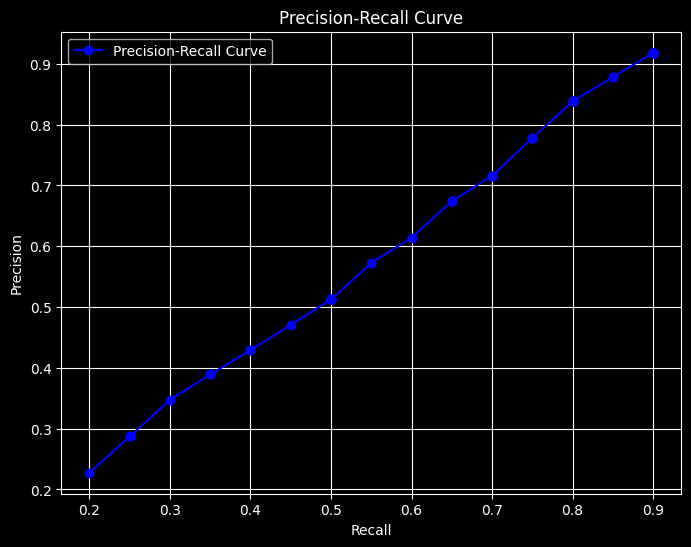

Actors Precision Recall Curve AUC: 0.4040625
Best F1 Score: Precision: 0.7912655472755432; Recall: 0.7680601477622986; F1-score: 0.7794901728630066;


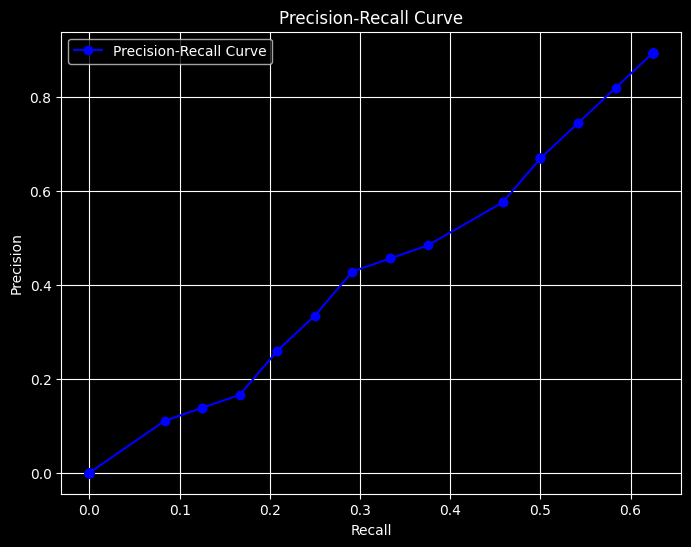

High Level Precision Recall Curve AUC: 0.259129050925926
Best F1 Score: Precision: 0.6518487930297852; Recall: 0.46112915873527527; F1-score: 0.540148138999939;


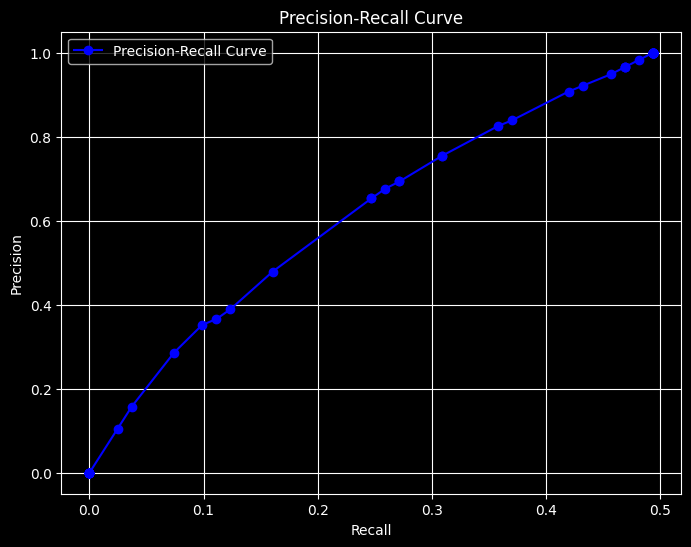

Low Level Goals Precision Recall Curve AUC: 0.2994013120784954
Best F1 Score: Precision: 0.7879252433776855; Recall: 0.378048300743103; F1-score: 0.5109443664550781;


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


-----------------------------------------------------------
ShotPromptingMode.ONE_SHOT, LLAMA ABLATION: True, PREPROCESSING: True
-----------------------------------------------------------


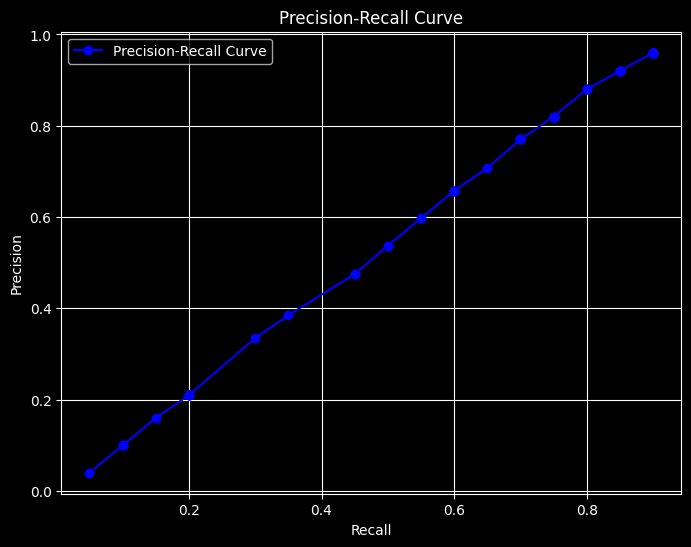

Actors Precision Recall Curve AUC: 0.43787500000000007
Best F1 Score: Precision: 0.7985391020774841; Recall: 0.7431807518005371; F1-score: 0.7698660492897034;


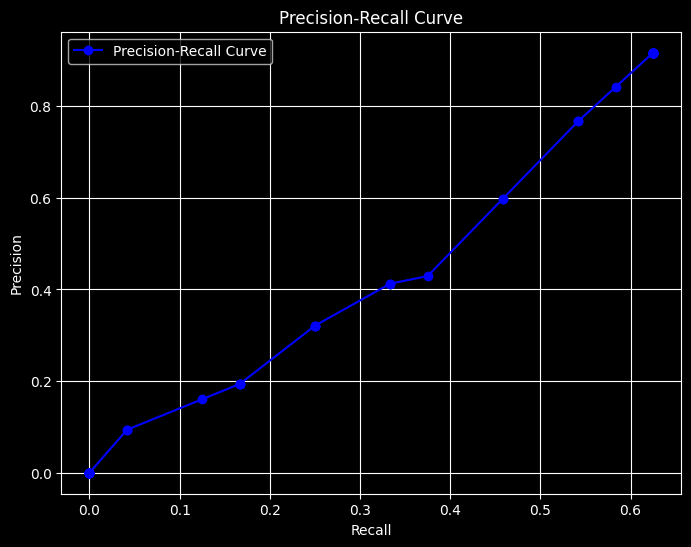

High Level Precision Recall Curve AUC: 0.25924479166666664
Best F1 Score: Precision: 0.6611086130142212; Recall: 0.4564104676246643; F1-score: 0.5400120615959167;


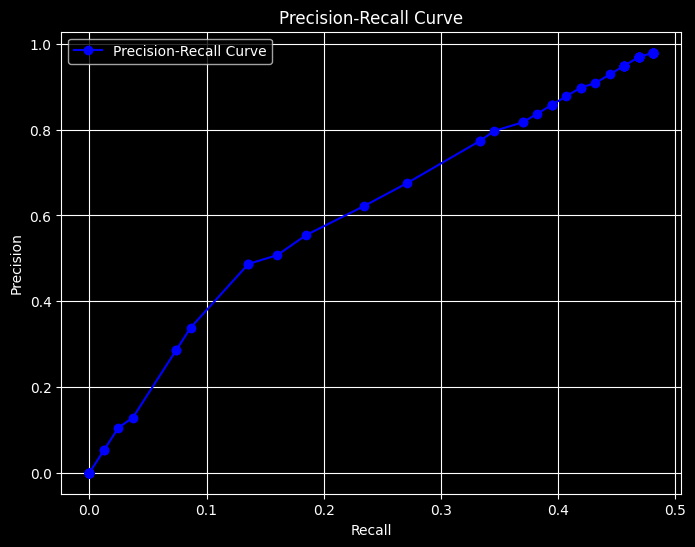

Low Level Goals Precision Recall Curve AUC: 0.287754776849427
Best F1 Score: Precision: 0.7624091506004333; Recall: 0.36138585209846497; F1-score: 0.49034541845321655;


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


-----------------------------------------------------------
ShotPromptingMode.FEW_SHOT, LLAMA ABLATION: True, PREPROCESSING: True
-----------------------------------------------------------


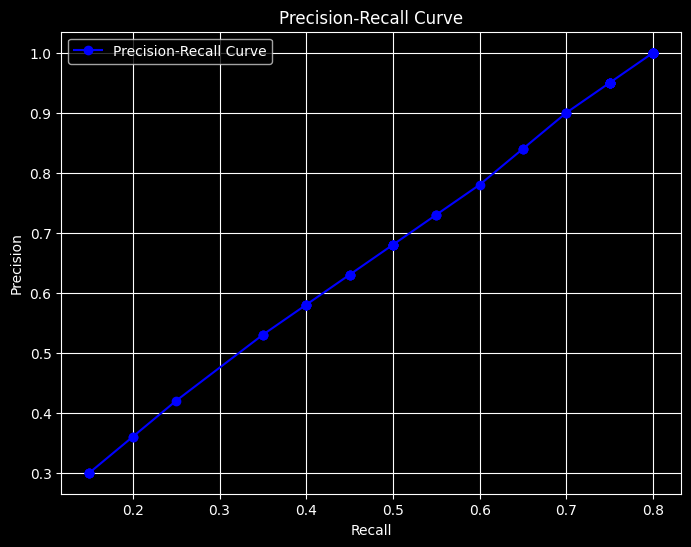

Actors Precision Recall Curve AUC: 0.42625
Best F1 Score: Precision: 0.8592333197593689; Recall: 0.6669893860816956; F1-score: 0.7510037422180176;


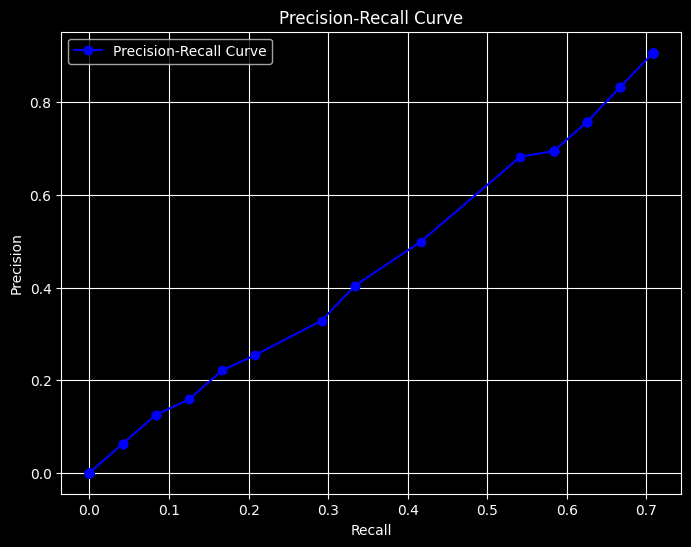

High Level Precision Recall Curve AUC: 0.30823412698412694
Best F1 Score: Precision: 0.6795080900192261; Recall: 0.5354188680648804; F1-score: 0.5989190340042114;


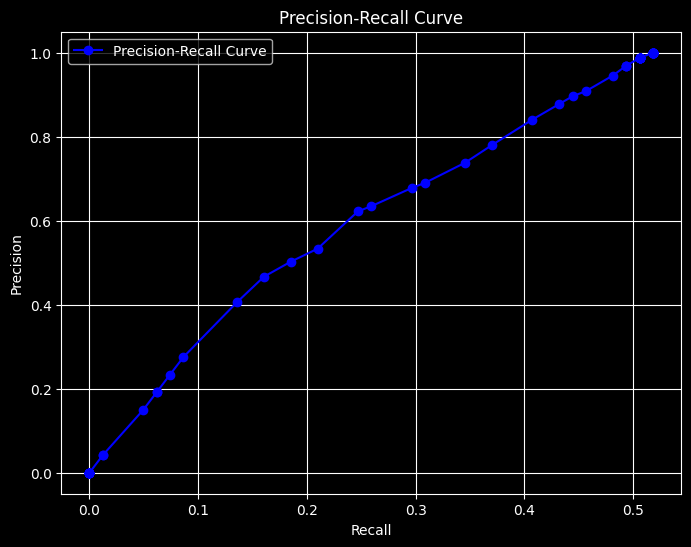

Low Level Goals Precision Recall Curve AUC: 0.3035131839658588
Best F1 Score: Precision: 0.7891643047332764; Recall: 0.398359090089798; F1-score: 0.5294561386108398;


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


-----------------------------------------------------------
ShotPromptingMode.ZERO_SHOT, LLAMA ABLATION: False, PREPROCESSING: True
-----------------------------------------------------------


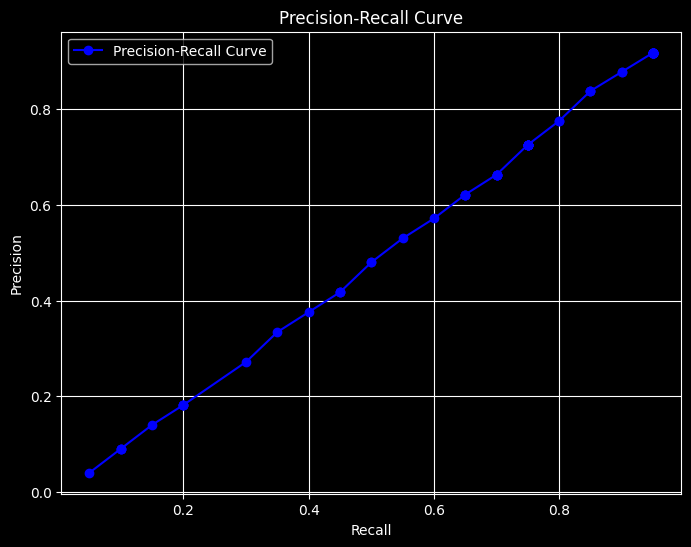

Actors Precision Recall Curve AUC: 0.4300833333333334
Best F1 Score: Precision: 0.7493666410446167; Recall: 0.7773558497428894; F1-score: 0.7631047368049622;


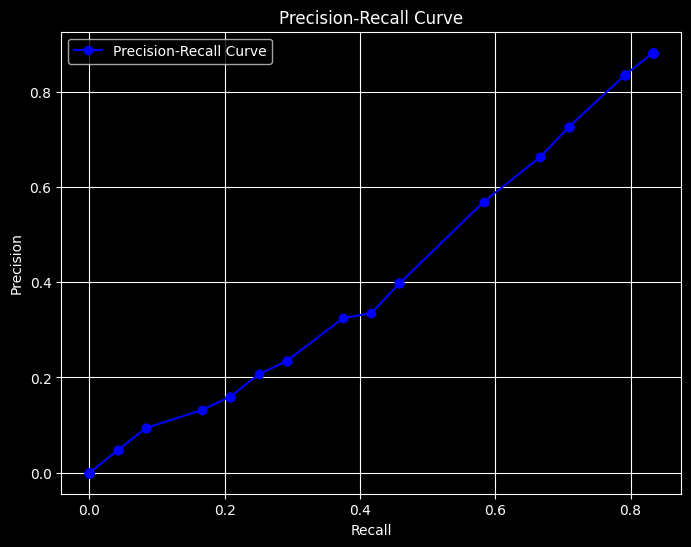

High Level Precision Recall Curve AUC: 0.3300419560185185
Best F1 Score: Precision: 0.6344467401504517; Recall: 0.611258327960968; F1-score: 0.6226366758346558;


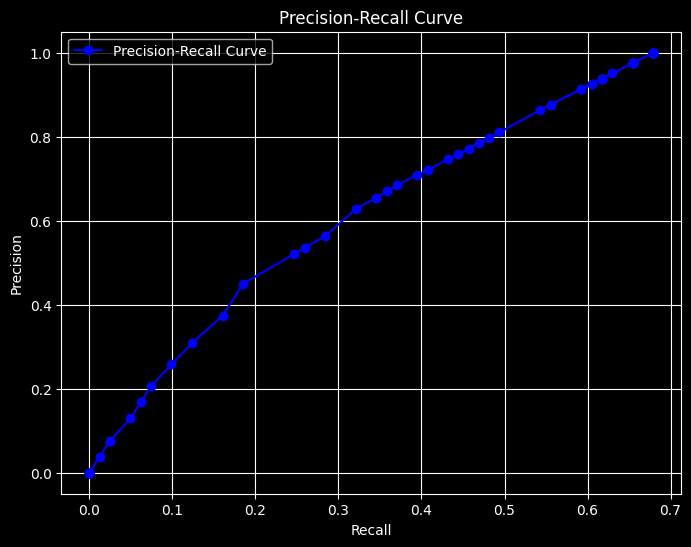

Low Level Goals Precision Recall Curve AUC: 0.40777718889858794
Best F1 Score: Precision: 0.7758433222770691; Recall: 0.5036435723304749; F1-score: 0.6107893586158752;


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


-----------------------------------------------------------
ShotPromptingMode.ONE_SHOT, LLAMA ABLATION: False, PREPROCESSING: True
-----------------------------------------------------------


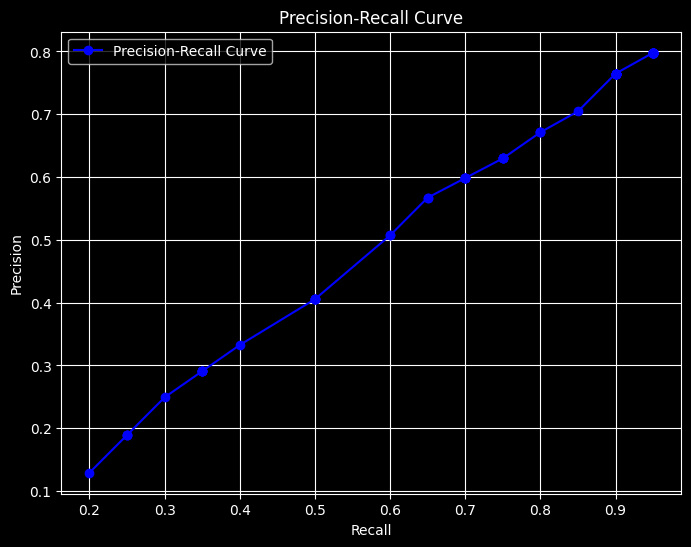

Actors Precision Recall Curve AUC: 0.3599166666666668
Best F1 Score: Precision: 0.676048219203949; Recall: 0.8042646646499634; F1-score: 0.734603762626648;


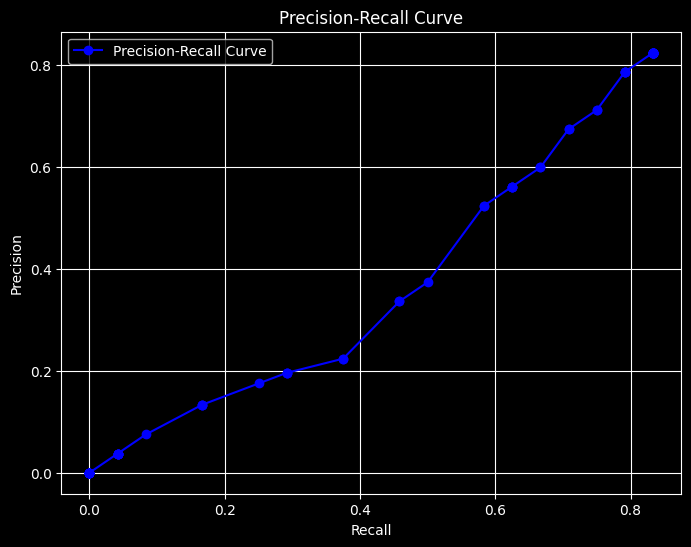

High Level Precision Recall Curve AUC: 0.29218749999999993
Best F1 Score: Precision: 0.5738092660903931; Recall: 0.5977458953857422; F1-score: 0.5855330228805542;


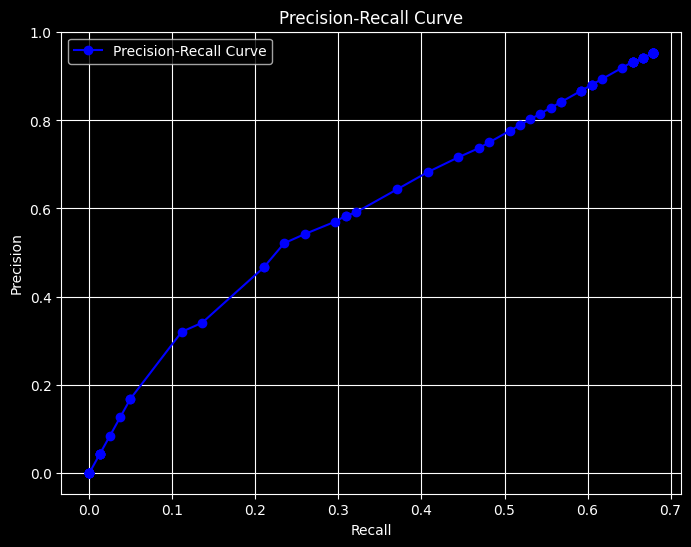

Low Level Goals Precision Recall Curve AUC: 0.39427137033749626
Best F1 Score: Precision: 0.7277861833572388; Recall: 0.49503853917121887; F1-score: 0.5892622470855713;


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


-----------------------------------------------------------
ShotPromptingMode.FEW_SHOT, LLAMA ABLATION: False, PREPROCESSING: True
-----------------------------------------------------------


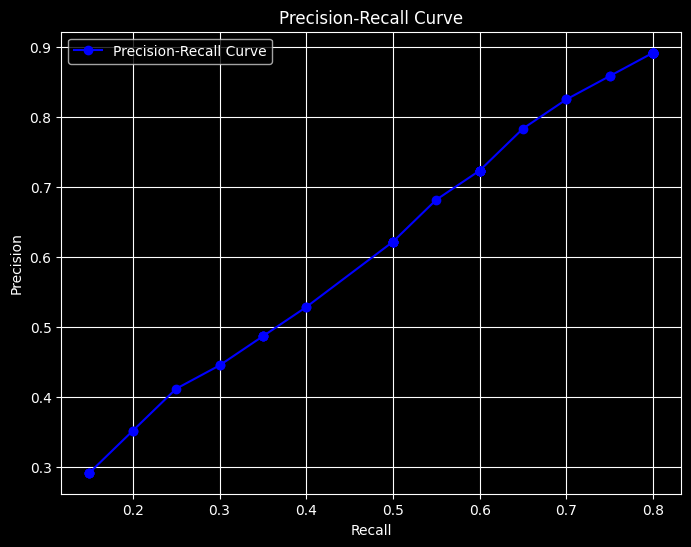

Actors Precision Recall Curve AUC: 0.3941666666666667
Best F1 Score: Precision: 0.7817485928535461; Recall: 0.6757928729057312; F1-score: 0.7249194979667664;


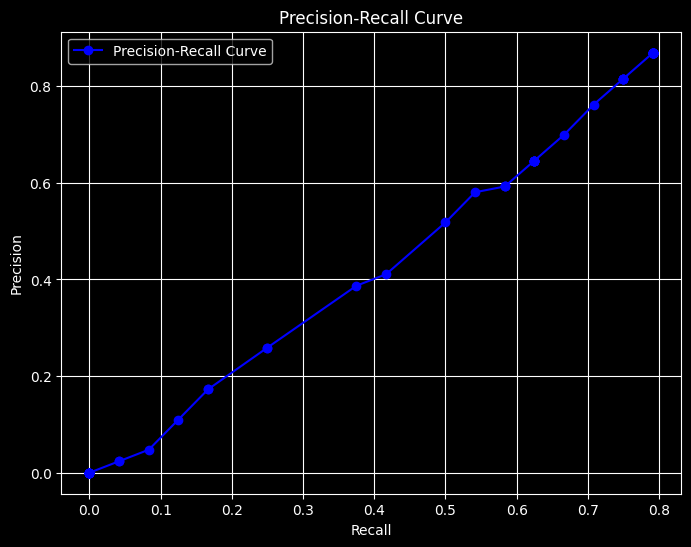

High Level Precision Recall Curve AUC: 0.3243427579365079
Best F1 Score: Precision: 0.6389802098274231; Recall: 0.5890341401100159; F1-score: 0.612991452217102;


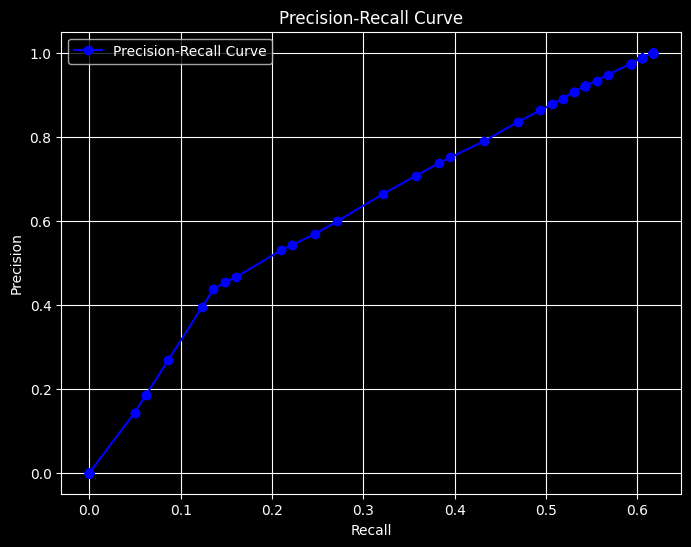

Low Level Goals Precision Recall Curve AUC: 0.3773463866570862
Best F1 Score: Precision: 0.7713621854782104; Recall: 0.455165296792984; F1-score: 0.5725061893463135;


In [2]:
from src.evaluation.goal_evaluator import GoalEvaluator
from examples.shot_learning import ShotPromptingMode
import json
import os

OUPUT_PATH = "output/"
os.makedirs(OUPUT_PATH, exist_ok=True)

PREPROCESSING = True #stop words remotion, stemming and lemmaization for the evaluation

prompting_eval = ShotPromptingMode.FEW_SHOT
SHOTS_NUMBER = prompting_eval
LLAMA_ABLATION_EVAL = True

for LLAMA_ABLATION_EVAL in [True, False]:

    for prompting_eval in [ShotPromptingMode.ZERO_SHOT, ShotPromptingMode.ONE_SHOT, ShotPromptingMode.FEW_SHOT]:
        SHOTS_NUMBER = prompting_eval

        generated_actors_eval = {}
        generated_hl_eval = {}
        generated_ll_eval = {}

        for gt in GROUNDTRUTHS:
            results = json.load(open(f"output/{gt['name']}_{prompting_eval.name}{"_noLlama" if LLAMA_ABLATION_EVAL  else ""}.json"))
            generated_actors_eval[gt["name"]] = results["actors"]
            generated_hl_eval[gt["name"]] = results["highLevelGoals"]
            generated_ll_eval[gt["name"]] = results["lowLevelGoals"]

        evaluator_actors = GoalEvaluator(preprocess = False)
        evaluator_hl = GoalEvaluator(preprocess = PREPROCESSING)
        evaluator_ll = GoalEvaluator(preprocess = PREPROCESSING)

        print("-----------------------------------------------------------")
        print(f"{prompting_eval}, LLAMA ABLATION: {LLAMA_ABLATION_EVAL}, PREPROCESSING: {PREPROCESSING}")
        print("-----------------------------------------------------------")

        #----------------------------EVALUATION------------------------------------------------------

        auc_prec_rec, best_f1 = evaluator_actors.print_prec_rec_curve(generated_actors_eval, manual_actors, output_file=f"{OUPUT_PATH}/actor_{SHOTS_NUMBER}{"_noLlama" if LLAMA_ABLATION_EVAL  else ""}.csv", save_to_file=True, rate_table=True)

        print("Actors Precision Recall Curve AUC:", auc_prec_rec)
        print(f"Best F1 Score: {best_f1}")

        auc_prec_rec, best_f1 = evaluator_hl.print_prec_rec_curve(generated_hl_eval, manual_hl, output_file=f"{OUPUT_PATH}/hl_{SHOTS_NUMBER}{"_noLlama" if LLAMA_ABLATION_EVAL  else ""}.csv", save_to_file=True, rate_table=True)

        print("High Level Precision Recall Curve AUC:", auc_prec_rec)
        print(f"Best F1 Score: {best_f1}")

        auc_prec_rec, best_f1 = evaluator_ll.print_prec_rec_curve(generated_ll_eval, manual_ll, output_file=f"{OUPUT_PATH}/ll_{SHOTS_NUMBER}{"_noLlama" if LLAMA_ABLATION_EVAL  else ""}.csv", save_to_file=True, rate_table=True)

        print("Low Level Goals Precision Recall Curve AUC:", auc_prec_rec)
        print(f"Best F1 Score: {best_f1}")

### APIs Extraction from Swagger

In [ ]:
print("API List STARTING...")
apiList = get_api_list_from_swagger(link=GROUNDTRUTH["swagger"])
print("API List DONE...")
print(apiList)

### APIs Mapping to Low Level Goals

In [ ]:
print("Mapping STARTING...")
mappings = generate_mapping_apis_goals(lowLevelGoals, apiList)
print("Mapping DONE")

In [ ]:
print(mappings[0].low_level_goal.high_level_associated.name)

### Mapping Table

In [ ]:
import json

print_api_goal_mapping(mappings)
with open(f"{OUPUT_PATH}/final_mapping_{SHOTS_NUMBER}.csv", "w") as f:
    f.write(json.dumps(mappings, default=lambda o: o.__dict__, indent=4))

## Cosine Similarities Between the Ground Truth and the Few-Shot Examples

In [7]:
from sentence_transformers import SentenceTransformer, util
from examples.shot_learning import example1_actors, example2_actors, example3_actors, example1_actors_withFeedback1, \
    example1_actors_withFeedback2, \
    example1_actors_withFeedback3, example1_actors_withFeedback4, example3_hl, example2_hl, example1_hl, \
    example1_hl_withFeedback1, example1_hl_withFeedback2, example1_hl_withFeedback3, example1_hl_withFeedback4, \
    example1_ll, example2_ll, example3_ll, example1_ll_withFeedback1, example1_ll_withFeedback2, \
    example1_ll_withFeedback3, example1_ll_withFeedback4
from groundtruth import GENOME, GESTAO_HOSPITAL, SIA_PROJECT_25_26, LONDON_AMBULANCE_SYSTEM
from extraction.extractor import generate_description

GROUNDTRUTHS = [GENOME, GESTAO_HOSPITAL, LONDON_AMBULANCE_SYSTEM, SIA_PROJECT_25_26, LONDON_AMBULANCE_SYSTEM]

# Load a model supporting long contexts (8k tokens)
# Supports 8192 context length natively
model = SentenceTransformer('nomic-ai/nomic-embed-text-v1.5', trust_remote_code=True)

def compute_sim_matrix(sentences1: list[str], sentences2: list[str]):

    # Compute embeddings
    embeddings1 = model.encode(sentences1, convert_to_tensor=True)
    embeddings2 = model.encode(sentences2, convert_to_tensor=True)

    # Compute the Cosine Similarity matrix
    # Result shape: [len(sentences1), len(sentences2)]
    return util.cos_sim(embeddings1, embeddings2)

def generate_summary(string: str)->str:
    sys_prompt = "You are an expert software engineer. You like to be precise, concise and direct."
    prompt = f"""Generate the summary for the following software engineering project description. Use at most on sentence. Generate only the summary, nothing else.

**Description:**
{string}

**Summary:**"""
    return generate_response_llama(sys_prompt, prompt)

evaluator = GoalEvaluator(preprocess=True)

descriptions = {gt["name"]: str(generate_description(gt["link-readme"]) if "link-readme" in gt.keys() else gt["description"]) for gt in GROUNDTRUTHS}
descriptions = {k: evaluator.preprocess_text(generate_summary(v)) for k, v in descriptions.items()}

shots_GPT_actors = [example1_actors, example2_actors, example3_actors]
for i, s in enumerate(shots_GPT_actors):
    shots_GPT_actors[i] = evaluator.preprocess_text(s)

shots_llama_actors = [example1_actors_withFeedback1, example1_actors_withFeedback2, example1_actors_withFeedback3, example1_actors_withFeedback4, ]
for i, s in enumerate(shots_llama_actors):
    shots_llama_actors[i] = evaluator.preprocess_text(s)

print("Similarity Matrix GPT Actors:")
for gt in GROUNDTRUTHS:
    description = descriptions[gt["name"]]
    print(gt["name"], ": \t\t", compute_sim_matrix([description], shots_GPT_actors))

print("\n\nSimilarity Matrix Llama Actors:")
for gt in GROUNDTRUTHS:
    description = descriptions[gt["name"]]
    print(gt["name"], ": \t\t", compute_sim_matrix([description], shots_llama_actors))


shots_GPT_hl = [example1_hl, example2_hl, example3_hl]
for i, s in enumerate(shots_GPT_hl):
    shots_GPT_hl[i] = evaluator.preprocess_text(s)

shots_llama_hl = [example1_hl_withFeedback1, example1_hl_withFeedback2, example1_hl_withFeedback3, example1_hl_withFeedback4, ]
for i, s in enumerate(shots_llama_hl):
    shots_llama_hl[i] = evaluator.preprocess_text(s)

print("---\n\nSimilarity Matrix GPT hl:")
for gt in GROUNDTRUTHS:
    description = descriptions[gt["name"]]
    print(gt["name"], ": \t\t", compute_sim_matrix([description], shots_GPT_hl))

print("\n\nSimilarity Matrix Llama hl:")
for gt in GROUNDTRUTHS:
    description = descriptions[gt["name"]]
    print(gt["name"], ": \t\t", compute_sim_matrix([description], shots_llama_hl))


shots_GPT_ll = [example1_ll, example2_ll, example3_ll]
for i, s in enumerate(shots_GPT_ll):
    shots_GPT_ll[i] = evaluator.preprocess_text(s)

shots_llama_ll = [example1_ll_withFeedback1, example1_ll_withFeedback2, example1_ll_withFeedback3, example1_ll_withFeedback4, ]
for i, s in enumerate(shots_llama_ll):
    shots_llama_ll[i] = evaluator.preprocess_text(s)

print("---\n\nSimilarity Matrix GPT ll:")
for gt in GROUNDTRUTHS:
    description = descriptions[gt["name"]]
    print(gt["name"], ": \t\t", compute_sim_matrix([description], shots_GPT_ll))

print("\n\nSimilarity Matrix Llama ll:")
for gt in GROUNDTRUTHS:
    description = descriptions[gt["name"]]
    print(gt["name"], ": \t\t", compute_sim_matrix([description], shots_llama_ll))

<All keys matched successfully>


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Similarity Matrix GPT Actors:
Genome Nexus : 		 tensor([[0.5498, 0.5036, 0.4878]])
Gestao Hospital : 		 tensor([[0.5146, 0.5120, 0.5391]])
London Ambulance Service : 		 tensor([[0.4788, 0.5475, 0.5694]])
SIA Project 25 26 : 		 tensor([[0.5182, 0.4672, 0.5168]])
London Ambulance Service : 		 tensor([[0.4788, 0.5475, 0.5694]])


Similarity Matrix Llama Actors:
Genome Nexus : 		 tensor([[0.5452, 0.5589, 0.5502, 0.5514]])
Gestao Hospital : 		 tensor([[0.5256, 0.5241, 0.5315, 0.5343]])
London Ambulance Service : 		 tensor([[0.4911, 0.5020, 0.5083, 0.5111]])
SIA Project 25 26 : 		 tensor([[0.5392, 0.5271, 0.5405, 0.5460]])
London Ambulance Service : 		 tensor([[0.4911, 0.5020, 0.5083, 0.5111]])
---

Similarity Matrix GPT hl:
Genome Nexus : 		 tensor([[0.5416, 0.5168, 0.4869]])
Gestao Hospital : 		 tensor([[0.4972, 0.5127, 0.5241]])
London Ambulance Service : 		 tensor([[0.4686, 0.5665, 0.5629]])
SIA Project 25 26 : 		 tensor([[0.5258, 0.4754, 0.5188]])
London Ambulance Service : 		 tensor([[